In [1]:
import importlib

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# Standard python packages
import os, sys, random, h5py, datetime, copy
from glob import glob

# Math packages
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas
import numpy

# Pytorch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn as nn
import torch

# SKlearn functions
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, StratifiedKFold
from sklearn.metrics import *
from sklearn.linear_model import LogisticRegression 

# Set syst path.
proj_path = "/net/pfeuffma/Research/proj-orthogonalisation/"
sys.path[0] = proj_path

# Niitorch imports
sys.path.insert(1, proj_path + "nitorch")
from nitorch.transforms import  *
from nitorch.data import show_brain

# Cocodeel imports
sys.path.insert(0, proj_path + "cocodeel")
from cocodeel.model import BaseNetwork
from cocodeel.posthoc_model import PostHocCovarNetwork
from cocodeel.dataset import CovarDataset
from cocodeel.trainer import covar_trainer

In [3]:
! gpustat

nyx                       Wed Feb 25 16:07:06 2026  590.48.01
[0] NVIDIA A100 80GB PCIe | 45°C,   0 % | 27908 / 81920 MB | pfeuffma(15408M) pfeuffma(12490M)
[1] NVIDIA A100 80GB PCIe | 44°C,   0 % | 18510 / 81920 MB | pfeuffma(9406M)


In [4]:
GPU = 1

In [5]:
# Set a random seed for replicable runs.
RANDOM_STATE=45
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [6]:
run_prefix = 'ADNI_SexAD_Synthetic_Study/{:%Y-%m-%d_%H-%M-%S}/'.format(datetime.datetime.now())
results_dir = proj_path+"logs/"+run_prefix

In [7]:
#data_adni = h5py.File("/ritter/share/projects/manuel_orthgnl/data/adni-screen-SUBJ-SEX-AGE-AD-n1682_downsampled.h5", 'r')
data_adni = h5py.File(proj_path + "data/adni-screen-SUBJ-SEX-AGE-AD-n1682_downsampled.h5", 'r')
data_adni.keys()

<KeysViewHDF5 ['AD', 'AGE', 'MONTH', 'SEX', 'X', 'i']>

In [8]:
i = data_adni['i'][:]

In [9]:
# Only keep first observation per subject
idx = np.unique(i, return_index=True)[1]
print("Number of unique subjects:", len(idx))

Number of unique subjects: 616


In [10]:
Xu = data_adni['X'][idx]

In [11]:
yu = np.float32(data_adni['AD'][idx])

In [12]:
Zu = np.float32(2 * data_adni['SEX'][idx] - 1.)  # Convert to -1 and 1.

In [13]:
print(Xu.shape)
print(Zu.shape)
print(yu.shape)

(616, 96, 114, 96)
(616,)
(616,)


In [14]:
# Split data into training and test set. Name training set "X" and test set "X_test"
X, X_test, y, y_test, Z, Z_test, i, i_test = train_test_split(Xu, yu, Zu, idx, test_size=0.2, random_state=RANDOM_STATE, stratify=yu)
print("Number of subjects in training set:", len(np.unique(i)))
print("Number of subjects in test set:", len(np.unique(i_test)))

Number of subjects in training set: 492
Number of subjects in test set: 124


In [15]:
# Table of the number of subjects with AD and CN in the training set by sex.
print(pandas.crosstab(y, Z, rownames=['AD'], colnames=['Sex']))

Sex  -1.0   1.0
AD             
0.0   147   212
1.0    69    64


In [16]:
print("Logistic Regression AD on SEX")
print(f":: Intercept: {LogisticRegression().fit(Z.reshape(-1, 1), y).intercept_[0]:.4f}")
print(f":: Sex Coeff: {LogisticRegression().fit(Z.reshape(-1, 1), y).coef_[0][0]:.4f}")

Logistic Regression AD on SEX
:: Intercept: -0.9772
:: Sex Coeff: -0.2184


In [17]:
# Table of the number of subjects with AD and CN in the test by sex.
print(pandas.crosstab(y_test, Z_test, rownames=['AD'], colnames=['Sex']))

Sex  -1.0   1.0
AD             
0.0    37    54
1.0    19    14


### Resample dataset with synthetic confounding

In [18]:
from scipy.stats import norm

# Sample from p(AD, sex).
def sample_ad_sex(n=1000, sex_coef=0.):
    # Distributional parameters
    mu_sex = 0.5
    mu_ad = -1
    # Sample from p(sex) given the total datset.
    sex = np.random.choice((-1,1), n, p=(1 - mu_sex, mu_sex))
    # Sample from p(AD|sex) given sex_coef.
    p_ad = 1/(1+np.exp(- mu_ad - sex_coef/2. * sex))
    ad = np.random.binomial(1, p_ad, len(sex))
    return sex, ad

In [19]:
# Sample from p(AD, age) and find the closest match in the real data.
def resample_synthetic(ydata, Zdata, n=1000, sex_coef=0.):
    sex, ad = sample_ad_sex(n, sex_coef)
    sample = []
    for i in range(n):
        # Index of observations with fitting ad status.
        idx = np.where(ydata==ad[i])[0]
        # Find all observations with same age and ad status in the real data.
        closest_idx = np.where(Zdata[idx] == sex[i])[0]
        # Udpate with the index of one of the the closest matches in the real data.
        sample.append(idx[np.random.choice(closest_idx)])
    return sample

#### Example resample for certain b_sex

In [20]:
idx = resample_synthetic(y, Z, 500, 0.)

sex, ad = Z[idx], y[idx]
print(pandas.crosstab(ad, sex, rownames=['AD'], colnames=['Sex']))

Sex  -1.0   1.0
AD             
0.0   184   190
1.0    71    55


In [21]:
idx = resample_synthetic(y, Z, 500, 1.)

sex, ad = Z[idx], y[idx]
print(pandas.crosstab(ad, sex, rownames=['AD'], colnames=['Sex']))

Sex  -1.0   1.0
AD             
0.0   220   148
1.0    40    92


In [22]:
idx = resample_synthetic(y, Z, 500, 2.)

sex, ad = Z[idx], y[idx]
print(pandas.crosstab(ad, sex, rownames=['AD'], colnames=['Sex']))

Sex  -1.0   1.0
AD             
0.0   233   120
1.0    29   118


### Cross Validation over synthetic folds

In [23]:
class StratifiedKFoldWithSyntheticResample:
    def __init__(self, n_splits=5, sex_coef=0., n_resamples=1000, shuffle=False, random_state=None):
        self.n_splits = n_splits
        self.sex_coef = sex_coef
        self.n_resamples = n_resamples
        self.random_state = random_state
        self.shuffle = shuffle
        self.cv = StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)
    
    def split(self, X, Z, y, groups=None):
        for train_ix, test_ix in self.cv.split(X,y):
            train_ix_rs = resample_synthetic(y[train_ix], Z[train_ix], self.n_resamples, self.sex_coef)
            train_ix_rs = train_ix[train_ix_rs]
            train_ix_rs, val_ix_rs = train_test_split(train_ix_rs, test_size=0.2, random_state=self.random_state, stratify=y[train_ix_rs])
            test_ix_rs = resample_synthetic(y[test_ix], Z[test_ix], self.n_resamples, self.sex_coef)
            test_ix_rs = test_ix[test_ix_rs]
            test_ix_fl = resample_synthetic(y[test_ix], Z[test_ix], self.n_resamples, -self.sex_coef)
            test_ix_fl = test_ix[test_ix_fl]
            yield train_ix_rs, val_ix_rs, test_ix_rs, test_ix_fl
        
    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits   

### Create metrics

In [24]:
# Deviance.
def deviance(y_true, p_pred):
    return -2*(log_loss(y_true, y_true) - log_loss(y_true, p_pred))

# Null deviance.
def null_deviance(y_true):
    p_null = np.mean(y_true)
    return deviance(y_true, np.ones_like(y_true) * p_null)

# Deviance explained.
def deviance_explained(y_true, p_pred):
    return 1 - deviance(y_true, p_pred)/null_deviance(y_true)

---
# Load trained models and Refit
### Compare NN and NN+Covar (Refit) on balanced and confouded data

In [25]:
# # ADNI

class ADNISixtyFourBackbone(nn.Module):
    """Reusable 3D-CNN network trunk for the ADNI dataset. 

    Input shape: (, 1, 182, 218, 182) or (, 1, 96, 114, 96) if downsampled.
    Output shape: (, num_features)
    """
    def __init__(self, out_features=32, drp_rate=0.3, downsampled=False):
        super().__init__()
        self.out_features = out_features
        self.drp_rate = drp_rate
        self.downsampled = downsampled
        if self.downsampled:
            self.conv_1 = nn.Sequential(
                        nn.Dropout3d(p=self.drp_rate),
                        nn.Conv3d(1, 16, kernel_size=5, stride=1, padding=0),
                        nn.BatchNorm3d(16),
                        nn.ELU(), 
                        nn.MaxPool3d(kernel_size=3, stride=3, padding=0)) 
        else:
            self.conv_1 = nn.Sequential(
                        nn.Dropout3d(p=self.drp_rate),
                        nn.Conv3d(1, 16, kernel_size=10, stride=2, padding=0),
                        nn.BatchNorm3d(16),
                        nn.ELU(), 
                        nn.MaxPool3d(kernel_size=3, stride=3, padding=0)) 
        self.conv_2 = nn.Sequential(
                        nn.Dropout3d(p=self.drp_rate),
                        nn.Conv3d(16, 32, kernel_size=5, stride=1, padding=0),
                        nn.BatchNorm3d(32),
                        nn.ELU(), 
                        nn.MaxPool3d(kernel_size=3, stride=2, padding=0))
        self.conv_3 = nn.Sequential(
                        nn.Conv3d(32, 64, kernel_size=3, stride=1, padding=0),
                        nn.BatchNorm3d(64),
                        nn.ELU())
        self.conv_4 = nn.Sequential(
                        nn.Conv3d(64, 128, kernel_size=3, stride=1, padding=0),
                        nn.BatchNorm3d(128),
                        nn.ELU())
        self.conv_5 = nn.Sequential(
                        nn.Conv3d(128, 64, kernel_size=3, stride=1, padding=0),
                        nn.BatchNorm3d(64),
                        nn.ELU())
        self.conv_6 = nn.Sequential(
                        nn.Conv3d(64, 64, kernel_size=3, stride=1, padding=0),
                        nn.BatchNorm3d(64),
                        nn.ELU(),
                        nn.MaxPool3d(kernel_size=4, stride=2, padding=0))
        self.fc = nn.Sequential(
                    nn.Linear(128, self.out_features),
                    nn.ELU())
        
    def forward(self, x):
        x = self.conv_1(x)
        x = self.conv_2(x)
        x = self.conv_3(x)
        x = self.conv_4(x)
        x = self.conv_5(x)
        x = self.conv_6(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x



In [26]:
def update_legacy_state_dict(state_dict):
    """Update legacy state dict to new naming scheme."""
    new_state_dict = copy.deepcopy(state_dict)
    # Remove pos weight if present.
    if 'loss_func.pos_weight' in new_state_dict:
        new_state_dict.pop('loss_func.pos_weight')
    # deep_predictor.weight --> fx.weight
    new_state_dict['fx.weight'] = new_state_dict.pop('deep_predictor.weight')
    # deep_predictor.bias --> intercept
    new_state_dict['intercept'] = new_state_dict.pop('deep_predictor.bias')
    # NEW: is_centered == False
    new_state_dict['is_centered'] = torch.tensor(False)
    # NEW: center_x.mean = torch.zeros(fx.weight.shape[1])
    new_state_dict['center_x.mean'] = torch.zeros(new_state_dict['fx.weight'].shape[1])
    # NEW: center_y.mean = torch.zeros(1)
    new_state_dict['center_y.mean'] = torch.zeros(1)
    
    return new_state_dict

In [27]:
class numpyCovarDataset(Dataset):
    def __init__(self, X, y, Z, transform=None, covar_transform=None):
        self.X = X
        if len(y.shape) == 1:
            y = y[:, None]
        self.y = y
        if len(Z.shape) == 1:
            Z = Z[:, None]
        self.Z = Z
        self.transform = transform
        self.covar_transform = covar_transform
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        image = self.X[idx]
        covar = self.Z[idx]
        if self.transform: 
            image = self.transform(image)
        if not torch.is_tensor(image):
            image = torch.tensor(self.X[idx], dtype=torch.float32)
        label = torch.tensor(self.y[idx], dtype=torch.float32)
        covar = torch.tensor(covar, dtype=torch.float32)
        return {"X" : image, "y" : label, "Z" : covar}
    

## Model Settings

In [28]:
batch_size = 48
num_workers = 16

trainer_params = {
    'device': 'cuda:1',
    'loss_fn': nn.BCEWithLogitsLoss(),
    'epochs': 250,
    'lr': 1e-4,
    'weight_decay': 1e-5,
    'patience': 12,
}

model_params = {
    'backbone': ADNISixtyFourBackbone,
    'backbone_params': {"out_features": 128, "downsampled": True},
    'num_covariates': 0,
    'link': 'logit'
}

# Define transforms.
augmentations = []  # Will be only applied to training data.
other_transforms = [IntensityRescale(masked=True), ToTensor()]  # # [0,1] intensity normalization will be applied to all data 

In [29]:
import gc
torch.cuda.empty_cache()
gc.collect()

572

# Model Training

In [30]:
test_dataset = numpyCovarDataset(X_test, y_test, Z_test, transform=transforms.Compose(other_transforms))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [ ]:
DEBUG = False

run_prefix = 'ADNI_SexAD_Synthetic_Study/{:%Y-%m-%d_%H-%M-%S}/'.format(datetime.datetime.now())
results_dir = proj_path+"logs/"+run_prefix
os.makedirs(results_dir, exist_ok=True)

# Randomly flip y with 0.2 probability for data augmentation and use y_flip for training.
# This ensures the task is harder and the confounder is learned more strongly.
np.random.seed(RANDOM_STATE)  # Make sure a seed is set for reproducibility.
flip_proba = 0.2
y_flip = np.where(np.random.binomial(1, flip_proba, len(y)), 1 - y, y)

for i, coef in enumerate([0.0, 1.0, 2.0]):
    print(f"Training with sex coefficient {coef}")
    # 5 fold CV with synthetic data.
    cv = StratifiedKFoldWithSyntheticResample(n_splits=10, sex_coef=coef, n_resamples=500, shuffle=True, random_state=RANDOM_STATE)
    for fold, (train_index, val_index, test_index, test_index_orig) in enumerate(cv.split(np.zeros(len(y_flip)), Z, y_flip)):
        print(f"  Fold {fold}")
        # Split data.
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y_flip[train_index], y_flip[val_index]
        Z_train, Z_val = Z[train_index], Z[val_index]
        # Create datasets.
        train_dataset = numpyCovarDataset(X_train, y_train, Z_train, transform=transforms.Compose(augmentations+other_transforms))
        val_dataset = numpyCovarDataset(X_val, y_val, Z_val, transform=transforms.Compose(other_transforms))
        # Create dataloaders.
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

        # Calculate pos loss weights for imbalanced classes.
        # Class weights.
        class_weights = sklearn.utils.class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        print(f"  :: balance_loss_weights = {class_weights}")
        pos_weight = torch.tensor(class_weights[1]/class_weights[0])
        trainer_params['loss_fn'] = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(GPU))

        # Train base neural network.
        net = covar_trainer(
            model=BaseNetwork,
            model_params={**model_params, "link": "identity"},  # trick to use pos_weight with logitsloss.
            train_loader=train_loader,
            val_loader=val_loader,
            **trainer_params
        ).center_effects(train_loader)
        net.link = "logit"  # Set link to logit for correct evaluation of metrics and saving.

        # Save balanced accuracy on validation set.
        val_preds = []
        with torch.no_grad():
            for batch in val_loader:
                Xb = batch['X'].to(GPU)
                val_preds.append(net(Xb).cpu().numpy())
        val_preds = np.concatenate(val_preds).flatten()
        val_bal_acc = balanced_accuracy_score(y_val, (val_preds >= 0.5).astype(int))
        print(f"    :: Vali balanced accuracy: {val_bal_acc:.4f}")

        # Test on original test set without synthetic resampling.
        test_preds = []
        with torch.no_grad():
            for batch in test_loader:
                Xb = batch['X'].to(GPU)
                test_preds.append(net(Xb).cpu().numpy())
        test_preds = np.concatenate(test_preds).flatten()
        test_bal_acc = balanced_accuracy_score(y_test, (test_preds >= 0.5).astype(int))
        print(f"    :: Test balanced accuracy: {test_bal_acc:.4f}")

        # Save model.
        chkpt_path = results_dir + f"/coef={coef}/neural_network_cv{fold}_n={len(train_dataset)}_pf={flip_proba}_val_bacc={val_bal_acc:.4f}_test_bacc={test_bal_acc:.4f}.pt"
        os.makedirs(os.path.dirname(chkpt_path), exist_ok=True)
        torch.save(net.state_dict(), chkpt_path)

---
# Analysis

### Load base models

In [40]:
chkpt_dir = "/net/pfeuffma/Research/proj-orthogonalisation/logs/ADNI_SexAD_Synthetic_Study/2026-02-11_14-20-34/"  #pf = 0.0
#chkpt_dir = "/net/pfeuffma/Research/proj-orthogonalisation/logs/ADNI_SexAD_Synthetic_Study/2026-02-12_10-59-23/"  #pf = 0.2
DEBUG = False

coefs = [0.0, 1.0, 2.0]

base_models = []
for i, coef in enumerate(coefs):
    dir = chkpt_dir + f"coef={coef}/"
    base_models.append([])
    for fold in range(10):
        # Grab models starting with "neural_network_cv{fold}_" from dir and load them.
        pattern = dir + f"neural_network_cv{fold}*.pt"
        paths = glob(pattern)
        assert len(paths) == 1, f"Expected one checkpoint for pattern {pattern}, but found {len(paths)}."
        path = paths[0]
        state_dict = torch.load(path, weights_only=False) #['state_dict']
        model = BaseNetwork(**model_params)
        #base_state_dict = update_legacy_state_dict(state_dict)
        model.load_state_dict(state_dict)
        base_models[i].append(model.eval())

### Center effects over train fold and fit posthoc model.

In [42]:
ph_models = []
pho_models = []

np.random.seed(RANDOM_STATE)  # Make sure a seed is set for reproducibility.
flip_proba = 0.0
y_flip = np.where(np.random.binomial(1, flip_proba, len(y)), 1 - y, y)

for i, coef in enumerate(coefs):

    print(f"Coefficient: {coef}")

    ph_models.append([])
    pho_models.append([])

    # 10 fold CV with synthetic data.
    cv = StratifiedKFoldWithSyntheticResample(n_splits=10, sex_coef=coef, n_resamples=500, shuffle=True, random_state=RANDOM_STATE)

    for fold, (train_index, val_index, test_index, test_index_orig) in enumerate(cv.split(np.zeros(len(y_flip)), Z, y_flip)):

        # Split data.
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y_flip[train_index], y_flip[val_index]
        Z_train, Z_val = Z[train_index], Z[val_index]

        # Create datasets.
        train_dataset = numpyCovarDataset(X_train, y_train, Z_train, transform=transforms.Compose(augmentations+other_transforms))
        val_dataset = numpyCovarDataset(X_val, y_val, Z_val, transform=transforms.Compose(other_transforms))

        # Create dataloaders.
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

        # Center effects.
        base_models[i][fold] = base_models[i][fold].to(GPU).center_effects(train_loader)

        # Fit posthoc covar model.
        phm = PostHocCovarNetwork(base_models[i][fold], num_covariates=1, orthogonalize=False).eval()
        phm = phm.to(GPU).fit(train_loader, val_loader, max_iters=200)
        ph_models[i].append(phm)

        # Print sex coefficient of posthoc model and logistic regression.
        lrm = LogisticRegression().fit(Z_train.reshape(-1, 1), y_train)
        print(f":: Fold {fold} :: PH coef: {phm.fz.weight.data.squeeze():.4f}, LR coef: {lrm.coef_[0][0]:.4f} (lambda: {phm.lam.data:.4f})")
        
        # Fit post hoc orthogonalized covar model.
        pho_models[i].append(copy.deepcopy(ph_models[i][fold]).eval())
        pho_models[i][fold] = pho_models[i][fold].to(GPU)
        pho_models[i][fold].orthogonalize = True
        pho_models[i][fold]._fit_orthogonalization(train_loader)

Coefficient: 0.0
IRLS did not converge after 200 iterations (delta_fx=6.9301e-07, delta_fz=3.2948e+00, lambda=1.5111e+02). Consider increasing max_iters or tol.
IRLS did not converge after 200 iterations (delta_fx=5.9364e-07, delta_fz=1.1102e+01, lambda=1.2522e+02). Consider increasing max_iters or tol.
IRLS did not converge after 200 iterations (delta_fx=2.6735e-07, delta_fz=1.1816e+01, lambda=1.0376e+02). Consider increasing max_iters or tol.
IRLS did not converge after 200 iterations (delta_fx=7.4257e-07, delta_fz=5.2546e-01, lambda=8.5981e+01). Consider increasing max_iters or tol.
IRLS did not converge after 200 iterations (delta_fx=6.5728e-08, delta_fz=1.2471e-01, lambda=7.1248e+01). Consider increasing max_iters or tol.
IRLS did not converge after 200 iterations (delta_fx=2.4754e-07, delta_fz=8.5828e-01, lambda=5.9039e+01). Consider increasing max_iters or tol.
IRLS did not converge after 200 iterations (delta_fx=3.8409e-08, delta_fz=2.7187e-01, lambda=4.8922e+01). Consider incr

---
## Evaluation on Test Dataset (Balanced!)

In [44]:
models = {
    'base': base_models,
    'posthoc': ph_models,
    'posthoc_orth': pho_models
}

In [45]:
# Get prediction over data loader.
def get_predictions(model, loader):
    model.eval()
    yhat, fxhat = [], []
    with torch.no_grad():
        for batch in loader:
            Xb = batch['X'].to(GPU)
            Zb = batch['Z'].to(GPU)
            yhat.append(model(Xb, Zb).cpu().numpy())
            fxhat.append(model.predict_fx(Xb, Zb).cpu().numpy())
    return {'y': np.concatenate(yhat), 'fx': np.concatenate(fxhat)}

In [46]:
# Get controlled prediciton of data loader and Ztrain.
def get_controlled_predictions(model, loader, Ztrain):
    model.eval()
    yhat_controlled = []
    with torch.no_grad():
        Ztrain = Ztrain.to(GPU)
        Ztrain = model.center_z(Ztrain)
        fztrain = model.predict_fz(Ztrain)
        for batch in loader:
            Xb = batch['X'].to(GPU)
            Zb = batch['Z'].to(GPU)
            # Controlled prediciton: For every Xb, average predictions over Ztrain.
            Hb = model.backbone(Xb)
            Hb = model.center_x(Hb)
            fx = model.fx(Hb)
            # Expand fx to match Ztrain shape.
            fx_expanded = fx.unsqueeze(1).expand(-1, Ztrain.shape[0], -1)
            if model.orthogonalize:
                fx_orth = model.orth(Ztrain)
                fx_expanded = fx_expanded - fx_orth
            eta_expanded = model.intercept + fx_expanded + fztrain
            yhat_controlled_batch = model.output_func(eta_expanded).mean(dim=1)
            yhat_controlled.append(yhat_controlled_batch.cpu().numpy())
    return {'y_controlled': np.concatenate(yhat_controlled)}

### A. Correlation of model predictions AND deep predictions.

In [47]:
# Evaluate models on test set (fold 0 for debug).
preds = []
for i, coef in enumerate(coefs):
    fpreds = []
    for fold in range(len(models['posthoc'][i])):
        print(f"Coefficient: {coef}, Fold: {fold}")
        fpreds.append({
            'base': get_predictions(models['base'][i][fold], test_loader),
            'posthoc': get_predictions(models['posthoc'][i][fold], test_loader),
            'posthoc_orth': get_predictions(models['posthoc_orth'][i][fold], test_loader)
        })
    preds.append(fpreds)

Coefficient: 0.0, Fold: 0
Coefficient: 0.0, Fold: 1
Coefficient: 0.0, Fold: 2
Coefficient: 0.0, Fold: 3
Coefficient: 0.0, Fold: 4
Coefficient: 0.0, Fold: 5
Coefficient: 0.0, Fold: 6
Coefficient: 0.0, Fold: 7
Coefficient: 0.0, Fold: 8
Coefficient: 0.0, Fold: 9
Coefficient: 1.0, Fold: 0
Coefficient: 1.0, Fold: 1
Coefficient: 1.0, Fold: 2
Coefficient: 1.0, Fold: 3
Coefficient: 1.0, Fold: 4
Coefficient: 1.0, Fold: 5
Coefficient: 1.0, Fold: 6
Coefficient: 1.0, Fold: 7
Coefficient: 1.0, Fold: 8
Coefficient: 1.0, Fold: 9
Coefficient: 2.0, Fold: 0
Coefficient: 2.0, Fold: 1
Coefficient: 2.0, Fold: 2
Coefficient: 2.0, Fold: 3
Coefficient: 2.0, Fold: 4
Coefficient: 2.0, Fold: 5
Coefficient: 2.0, Fold: 6
Coefficient: 2.0, Fold: 7
Coefficient: 2.0, Fold: 8
Coefficient: 2.0, Fold: 9


In [48]:
preds_controlled = []

for i, coef in enumerate(coefs):
    fpreds = []
    for fold, (train_index, _, _, _) in enumerate(cv.split(np.zeros(len(y_flip)), Z, y_flip)):
        print(f"Coefficient: {coef}, Fold: {fold}")
        Ztrain = torch.tensor(Z[train_index, np.newaxis], dtype=torch.float32)
        fpreds.append({
            'posthoc': get_controlled_predictions(models['posthoc'][i][fold], test_loader, Ztrain),
            'posthoc_orth': get_controlled_predictions(models['posthoc_orth'][i][fold], test_loader, Ztrain)
        })
    preds_controlled.append(fpreds)

Coefficient: 0.0, Fold: 0
Coefficient: 0.0, Fold: 1
Coefficient: 0.0, Fold: 2
Coefficient: 0.0, Fold: 3
Coefficient: 0.0, Fold: 4
Coefficient: 0.0, Fold: 5
Coefficient: 0.0, Fold: 6
Coefficient: 0.0, Fold: 7
Coefficient: 0.0, Fold: 8
Coefficient: 0.0, Fold: 9
Coefficient: 1.0, Fold: 0
Coefficient: 1.0, Fold: 1
Coefficient: 1.0, Fold: 2
Coefficient: 1.0, Fold: 3
Coefficient: 1.0, Fold: 4
Coefficient: 1.0, Fold: 5
Coefficient: 1.0, Fold: 6
Coefficient: 1.0, Fold: 7
Coefficient: 1.0, Fold: 8
Coefficient: 1.0, Fold: 9
Coefficient: 2.0, Fold: 0
Coefficient: 2.0, Fold: 1
Coefficient: 2.0, Fold: 2
Coefficient: 2.0, Fold: 3
Coefficient: 2.0, Fold: 4
Coefficient: 2.0, Fold: 5
Coefficient: 2.0, Fold: 6
Coefficient: 2.0, Fold: 7
Coefficient: 2.0, Fold: 8
Coefficient: 2.0, Fold: 9


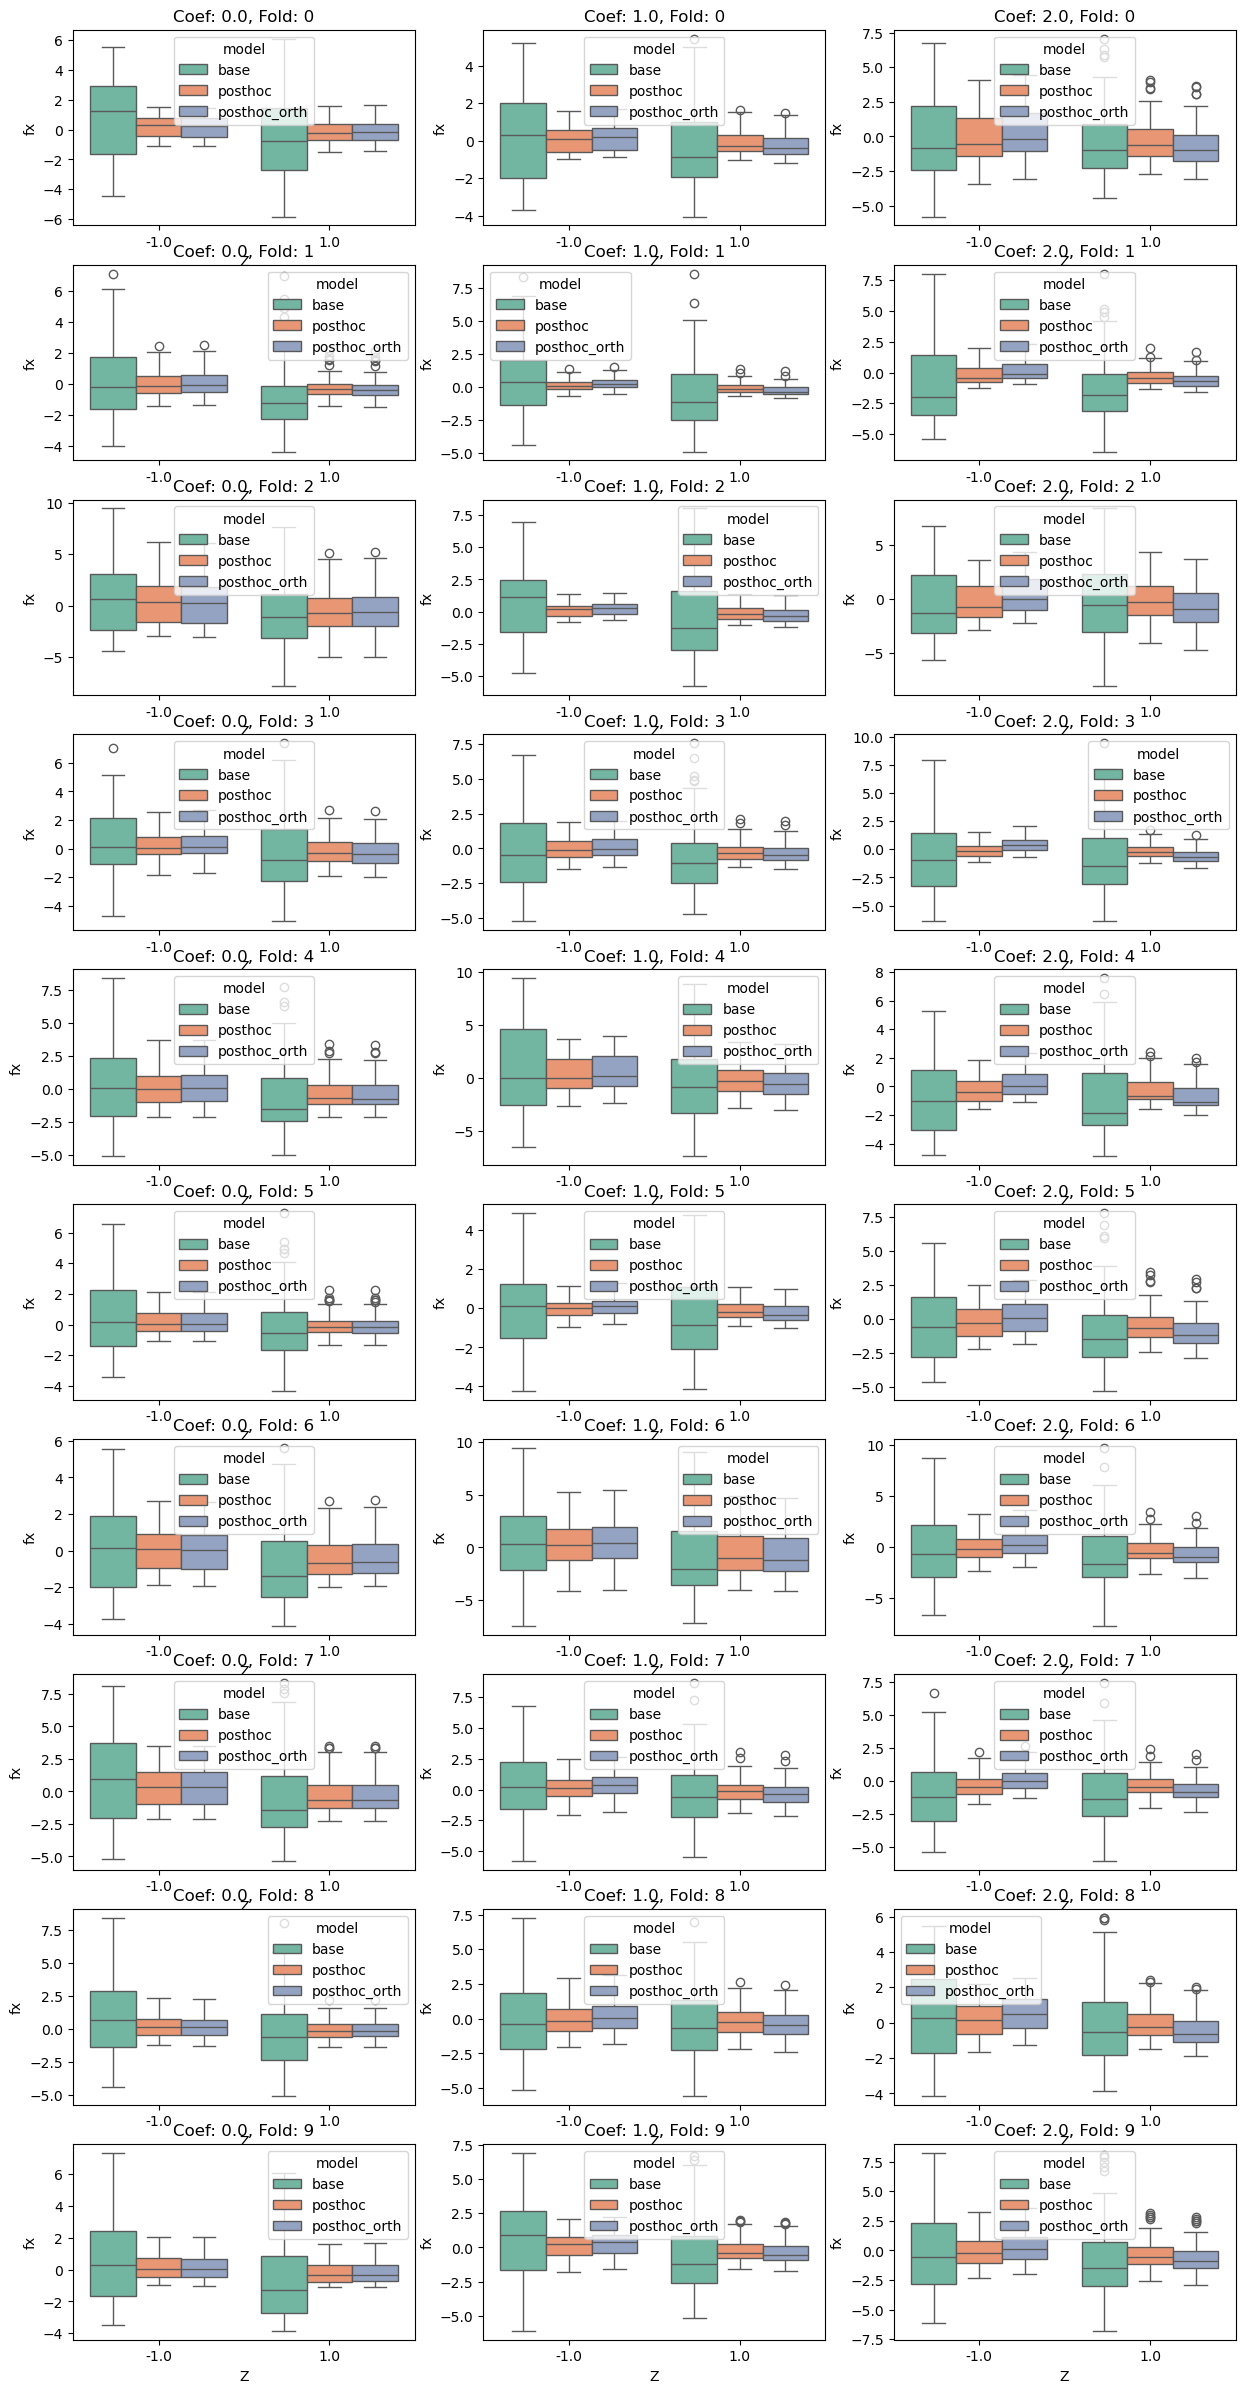

In [50]:
# Create a 2 (cols) x 5 (folds) grid of boxplots comparing fx of base and posthoc models for each fold and coef.
fig, axes = plt.subplots(nrows=len(preds[0]), ncols=len(preds), figsize=(15, 30))

for coef in range(len(coefs)):
    for fold in range(len(preds[coef])):
        df = pandas.DataFrame({
            'fx': np.concatenate([
                preds[coef][fold]['base']['fx'].squeeze(),
                preds[coef][fold]['posthoc']['fx'].squeeze(),
                preds[coef][fold]['posthoc_orth']['fx'].squeeze(),
                ]),
            'y': np.concatenate([
                preds[coef][fold]['base']['y'].squeeze(),
                preds[coef][fold]['posthoc']['y'].squeeze(),
                preds[coef][fold]['posthoc_orth']['y'].squeeze()
                ]),
            'model': ['base'] * len(preds[coef][fold]['base']['fx']) + ['posthoc'] * len(preds[coef][fold]['posthoc']['fx']) + ['posthoc_orth'] * len(preds[coef][fold]['posthoc_orth']['fx']),
            'Z': np.concatenate([Z_test, Z_test, Z_test])})
        sns.boxplot(data=df, x='Z', y='fx', hue='model', palette='Set2', ax=axes[fold, coef])
        axes[fold, coef].set_title(f"Coef: {coefs[coef]}, Fold: {fold}")

### Plotting model predictions versus balanced model predictions


In [62]:
model_names = ['base', 'posthoc', 'posthoc_orth']
# Average predictions over folds per observation
preds_avg = []
for i, coef in enumerate(coefs):
    model_preds = {model_name: {'y':[], 'fx':[]} for model_name in model_names}
    for fold in range(10):
        for model_name in model_names:
            model_preds[model_name]['y'].append(preds[i][fold][model_name]['y'])
            model_preds[model_name]['fx'].append(preds[i][fold][model_name]['fx'])
    model_preds_avg = {model_name: {
        'y': np.mean(model_preds[model_name]['y'], axis=0),
        'fx': np.mean(model_preds[model_name]['fx'], axis=0)
    } for model_name in model_names}
    preds_avg.append(model_preds_avg)
# Average controlled predictions over folds per observation
preds_controlled_avg = []
for i, coef in enumerate(coefs):
    model_preds = {model_name: [] for model_name in ['posthoc', 'posthoc_orth']}
    for fold in range(10):
        for model_name in ['posthoc', 'posthoc_orth']:
            model_preds[model_name].append(preds_controlled[i][fold][model_name]['y_controlled'])
    model_preds_avg = {model_name: np.mean(model_preds[model_name], axis=0) for model_name in ['posthoc', 'posthoc_orth']}
    preds_controlled_avg.append(model_preds_avg)

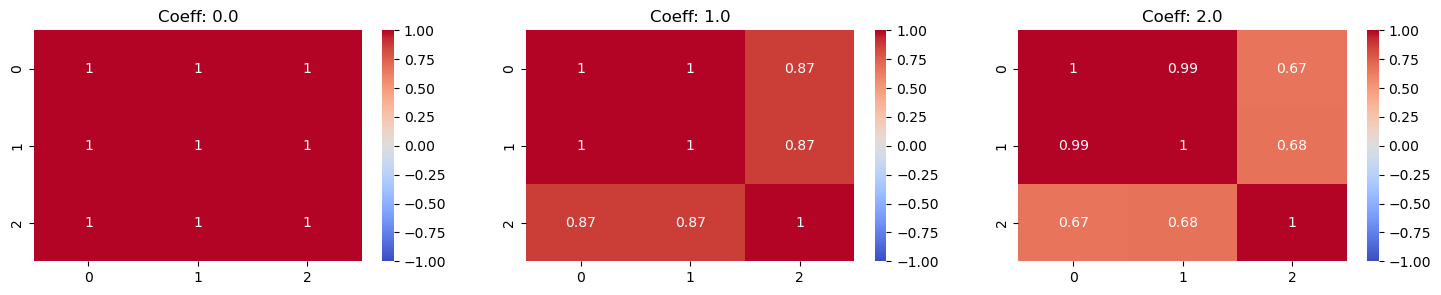

In [63]:
# Plot correlation matrices of predictions for each model and coefficient.
fix, axes = plt.subplots(nrows=1, ncols=len(coefs), figsize=(18, 3))
for i, coef in enumerate(coefs):
    ax = axes[i]
    title = f"Coeff: {coef}"
    data = np.array([preds_avg[i][model_name]['fx'].flatten() for model_name in model_names])
    corr = np.corrcoef(data)
    ax.set_title(title)
    sns.heatmap(corr, annot=True, ax=ax, vmin=-1, vmax=1, cmap='coolwarm')

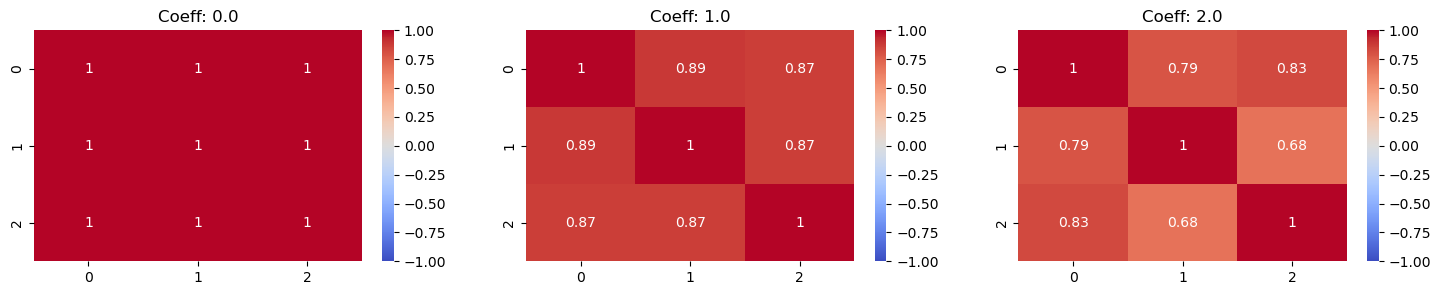

In [64]:
# Plot correlation matrices of posthoc predictions and balanced baseline.
fix, axes = plt.subplots(nrows=1, ncols=len(coefs), figsize=(18, 3))
for i, coef in enumerate(coefs):
    ax = axes[i]
    title = f"Coeff: {coef}"
    data = np.array([preds_avg[i][model_name]['fx'].flatten() for model_name in model_names])
    data[0,:] = np.array(preds_avg[0]['base']['fx']).flatten()
    corr = np.corrcoef(data)
    ax.set_title(title)
    sns.heatmap(corr, annot=True, ax=ax, vmin=-1, vmax=1, cmap='coolwarm')

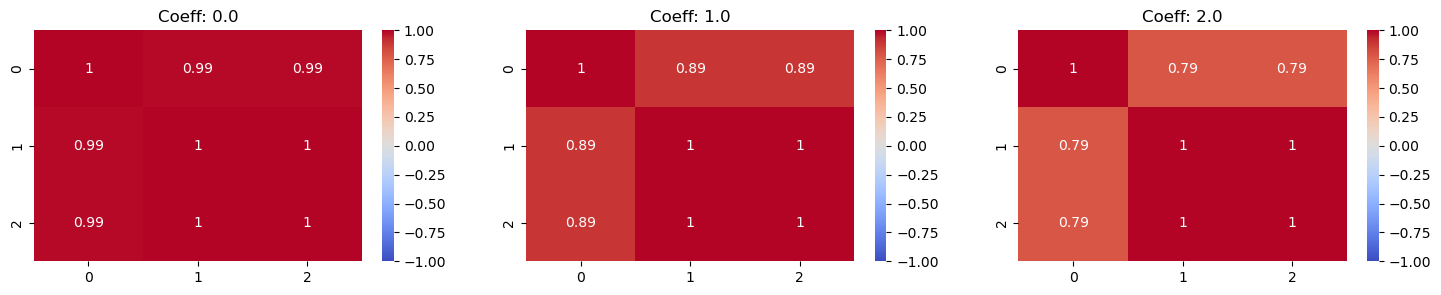

In [65]:
# Plot correlation matrices of controlled predictions for each model and coefficient.
fix, axes = plt.subplots(nrows=1, ncols=len(coefs), figsize=(18, 3))
for i, coef in enumerate(coefs):
    ax = axes[i]
    title = f"Coeff: {coef}"
    data = np.array([
        preds_avg[0]['base']['y'].flatten(),
        preds_controlled_avg[i]['posthoc'].flatten(),
        preds_controlled_avg[i]['posthoc_orth'].flatten()
    ])
    corr = np.corrcoef(data)
    ax.set_title(title)
    sns.heatmap(corr, annot=True, ax=ax, vmin=-1, vmax=1, cmap='coolwarm')

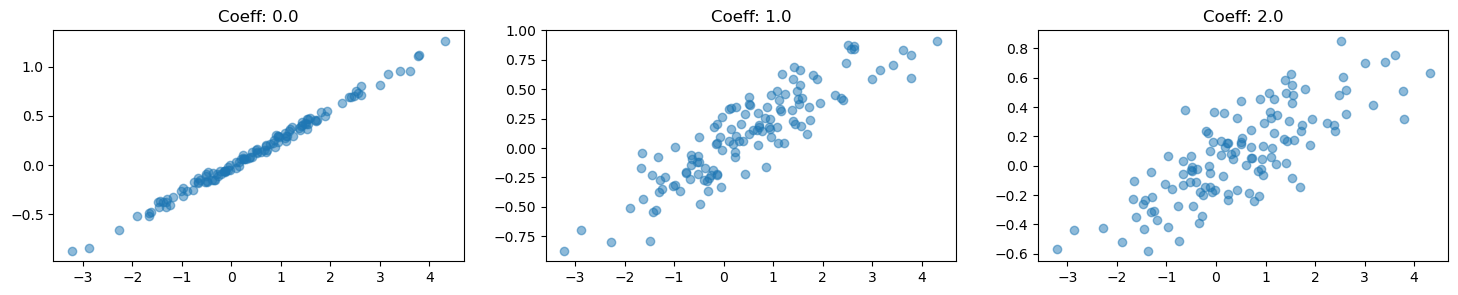

In [66]:
# Scatterplot of predictions of posthoc and base (coef = 0.0).
fig, axes = plt.subplots(nrows=1, ncols=len(coefs), figsize=(18, 3))
for i, coef in enumerate(coefs):
    ax = axes[i]
    title = f"Coeff: {coef}"
    ax.scatter(preds_avg[0]['base']['fx'], preds_avg[i]['posthoc']['fx'], label='posthoc', alpha=0.5)
    #ax.scatter(preds_avg[0]['base']['fx'], preds_avg[i]['posthoc_orth']['fx'], label='posthoc_orth', alpha=0.5)
    # Add line y=x for reference.
    #ax.plot([-20, 20], [-20, 20], 'k--', label='y=x')
    ax.set_title(title)
    #ax.legend()

### Plot balanced accuracy boxplots (using folds) over strenght of coef.

In [ ]:
# Boxplot of balanced accuracy for each model and coefficient. Use controlled predictions of y.

### B. Balanced Accuracy ($y$, $\hat y$)

In [67]:
for i, coef in enumerate(coefs):
    print(f"Coefficient: {coef}")
    for model_name in model_names:
        auc, dev_exp, acc, bal_acc = np.array([]), np.array([]), np.array([]), np.array([])
        for fold in range(5):
            y_pred = preds[i][fold][model_name]['y'].flatten()
            auc = np.append(auc, roc_auc_score(y_test, y_pred))
            dev_exp = np.append(dev_exp, deviance_explained(y_test, y_pred))
            acc = np.append(acc, accuracy_score(y_test, (y_pred >= 0.5).astype(int)))
            bal_acc = np.append(bal_acc, balanced_accuracy_score(y_test, (y_pred >= 0.5).astype(int)))
        print(f"  Model: {model_name} \t{'\t' if model_name == 'base' else ''}  AUC: {auc.mean():.4f} +- {auc.std():.4f},  Deviance Explained: {dev_exp.mean():.4f} +- {dev_exp.std():.4f},  Accuracy: {acc.mean():.4f} +- {acc.std():.4f},  Balanced Accuracy: {bal_acc.mean():.4f} +- {bal_acc.std():.4f}")

Coefficient: 0.0
  Model: base 		  AUC: 0.7643 +- 0.0302,  Deviance Explained: -0.1121 +- 0.1137,  Accuracy: 0.7081 +- 0.0308,  Balanced Accuracy: 0.7258 +- 0.0398
  Model: posthoc 	  AUC: 0.7538 +- 0.0292,  Deviance Explained: 0.1030 +- 0.0262,  Accuracy: 0.7371 +- 0.0065,  Balanced Accuracy: 0.5176 +- 0.0220
  Model: posthoc_orth 	  AUC: 0.7538 +- 0.0292,  Deviance Explained: 0.1030 +- 0.0262,  Accuracy: 0.7371 +- 0.0065,  Balanced Accuracy: 0.5176 +- 0.0220
Coefficient: 1.0
  Model: base 		  AUC: 0.6987 +- 0.0467,  Deviance Explained: -0.1658 +- 0.1302,  Accuracy: 0.6387 +- 0.0277,  Balanced Accuracy: 0.6225 +- 0.0349
  Model: posthoc 	  AUC: 0.6112 +- 0.0466,  Deviance Explained: 0.0232 +- 0.0324,  Accuracy: 0.7452 +- 0.0065,  Balanced Accuracy: 0.5386 +- 0.0132
  Model: posthoc_orth 	  AUC: 0.6112 +- 0.0466,  Deviance Explained: 0.0232 +- 0.0324,  Accuracy: 0.7452 +- 0.0065,  Balanced Accuracy: 0.5386 +- 0.0132
Coefficient: 2.0
  Model: base 		  AUC: 0.6735 +- 0.0629,  Deviance Ex

#### Balanced Accuracy ($y$, $\hat y_{controlled}$)

In [68]:
for i, coef in enumerate(coefs):
    print(f"Coefficient: {coef}")
    for model_name in ['posthoc', 'posthoc_orth']:
        auc, dev_exp, acc, bal_acc = np.array([]), np.array([]), np.array([]), np.array([])
        for fold in range(5):
            y_pred = preds_controlled[i][fold][model_name]['y_controlled'].flatten()
            auc = np.append(auc, roc_auc_score(y_test, y_pred))
            dev_exp = np.append(dev_exp, deviance_explained(y_test, y_pred))
            acc = np.append(acc, accuracy_score(y_test, (y_pred >= 0.5).astype(int)))
            bal_acc = np.append(bal_acc, balanced_accuracy_score(y_test, (y_pred >= 0.5).astype(int)))
        print(f"  Model: {model_name} \t  AUC: {auc.mean():.4f} +- {auc.std():.4f},  Deviance Explained: {dev_exp.mean():.4f} +- {dev_exp.std():.4f},  Accuracy: {acc.mean():.4f} +- {acc.std():.4f},  Balanced Accuracy: {bal_acc.mean():.4f} +- {bal_acc.std():.4f}")

Coefficient: 0.0
  Model: posthoc 	  AUC: 0.7590 +- 0.0309,  Deviance Explained: 0.1041 +- 0.0259,  Accuracy: 0.7355 +- 0.0032,  Balanced Accuracy: 0.5146 +- 0.0164
  Model: posthoc_orth 	  AUC: 0.7590 +- 0.0309,  Deviance Explained: 0.1041 +- 0.0259,  Accuracy: 0.7355 +- 0.0032,  Balanced Accuracy: 0.5146 +- 0.0164
Coefficient: 1.0
  Model: posthoc 	  AUC: 0.7024 +- 0.0454,  Deviance Explained: 0.0761 +- 0.0221,  Accuracy: 0.7419 +- 0.0072,  Balanced Accuracy: 0.5209 +- 0.0119
  Model: posthoc_orth 	  AUC: 0.7024 +- 0.0454,  Deviance Explained: 0.0761 +- 0.0221,  Accuracy: 0.7419 +- 0.0072,  Balanced Accuracy: 0.5209 +- 0.0119
Coefficient: 2.0
  Model: posthoc 	  AUC: 0.6690 +- 0.0634,  Deviance Explained: 0.0578 +- 0.0387,  Accuracy: 0.7403 +- 0.0079,  Balanced Accuracy: 0.5237 +- 0.0223
  Model: posthoc_orth 	  AUC: 0.6690 +- 0.0634,  Deviance Explained: 0.0577 +- 0.0385,  Accuracy: 0.7387 +- 0.0097,  Balanced Accuracy: 0.5226 +- 0.0226


### C. LRP Heatmaps using Zennit

In [38]:
import types

def modified_forward(self, x):
    fx = self.predict_fx(x, z=self.Z)
    return fx

In [39]:
from zennit.composites import EpsilonGammaBox, EpsilonPlus
from zennit.canonizers import SequentialMergeBatchNorm
from zennit.attribution import Gradient

canonizers = [SequentialMergeBatchNorm()]
#composite = EpsilonGammaBox(low=0., high=1., canonizers=canonizers)
composite = EpsilonPlus(canonizers=canonizers)

coefs = [0.0, 1.0, 2.0]
model_names = ['base', 'posthoc', 'posthoc_orth']

relevances = []

for i, coef in enumerate(coefs):
    print(f"Coefficient: {coef}")

    model_relevances = {
        'base': [],
        'posthoc': [],
        'posthoc_orth': []
    }

    for model_name in model_names:
        print(f"  Model: {model_name}")
        print(f"    Fold: ", end='')

        for fold in range(10):
            print(f"{fold} ", end='')

            # Prepare model for zennit.
            model = copy.deepcopy(models[model_name][i][fold])  # Take fold 0 for debug.
            model.forward = types.MethodType(modified_forward, model)
            model = model.to(GPU)
            model.eval()

            relevance = torch.zeros_like(test_dataset[0]['X'])

            n = 0
            #for j in range(len(test_dataset)):
            for j in range(50):  # Debug
                yin = test_dataset[j]['y'].unsqueeze(0)
                Xin = test_dataset[j]['X'].unsqueeze(0).to(GPU)
                Zin = test_dataset[j]['Z'].unsqueeze(0).to(GPU)
                if yin == 0:  # Skip controls for clarity.
                    continue
                if Zin == 0:  # Only female for clarity.
                    continue
                model.Z = Zin.to(GPU)
                model.Z.requires_grad = True

                with Gradient(model=model, composite=composite) as attributor:
                    out, rel = attributor(Xin)
                rel = rel / rel.abs().sum()  # Normalize relevance.
                relevance += rel.cpu().squeeze()
                n += 1

            relevance = relevance / n

            model_relevances[model_name].append(relevance.squeeze().numpy())

        print("")
        
    relevances.append(model_relevances)

Coefficient: 0.0
  Model: base
    Fold: 0 1 2 3 4 5 6 7 8 9 
  Model: posthoc
    Fold: 0 1 2 

IndexError: list index out of range

In [ ]:
# Post process relevancy maps across folds by rank-based stability and averaging.
# For each fold:
#  1. Rank pixel by absolute value.
#  2. Create mask of top k% pixels.
#  3. Intersect masks across folds.
# Average relevances across folds within the intersection mask.
# Calculate absolute value.
k = 0.25
relevances_processed = []
for i, coef in enumerate(coefs):
    print(f"Coefficient: {coef}")
    model_relevances = copy.deepcopy(relevances[i])
    model_relevances_processed = {}
    for model_name in model_names:
        print(f"  Model: {model_name}")
        fold_masks = []
        for fold in range(5):
            rel = model_relevances[model_name][fold]
            abs_rel = np.abs(rel)
            threshold = np.percentile(abs_rel, 100 - k*100)
            mask = abs_rel >= threshold
            fold_masks.append(mask)
        intersection_mask = np.logical_and.reduce(fold_masks)
        avg_relevance = np.mean(model_relevances[model_name], axis=0)
        avg_relevance_masked = avg_relevance * intersection_mask
        model_relevances_processed[model_name] = avg_relevance_masked
    relevances_processed.append(model_relevances_processed)

Coefficient: 0.0
  Model: base
  Model: posthoc
  Model: posthoc_orth
Coefficient: 1.0
  Model: base
  Model: posthoc
  Model: posthoc_orth
Coefficient: 2.0
  Model: base
  Model: posthoc
  Model: posthoc_orth


IndexError: list index out of range

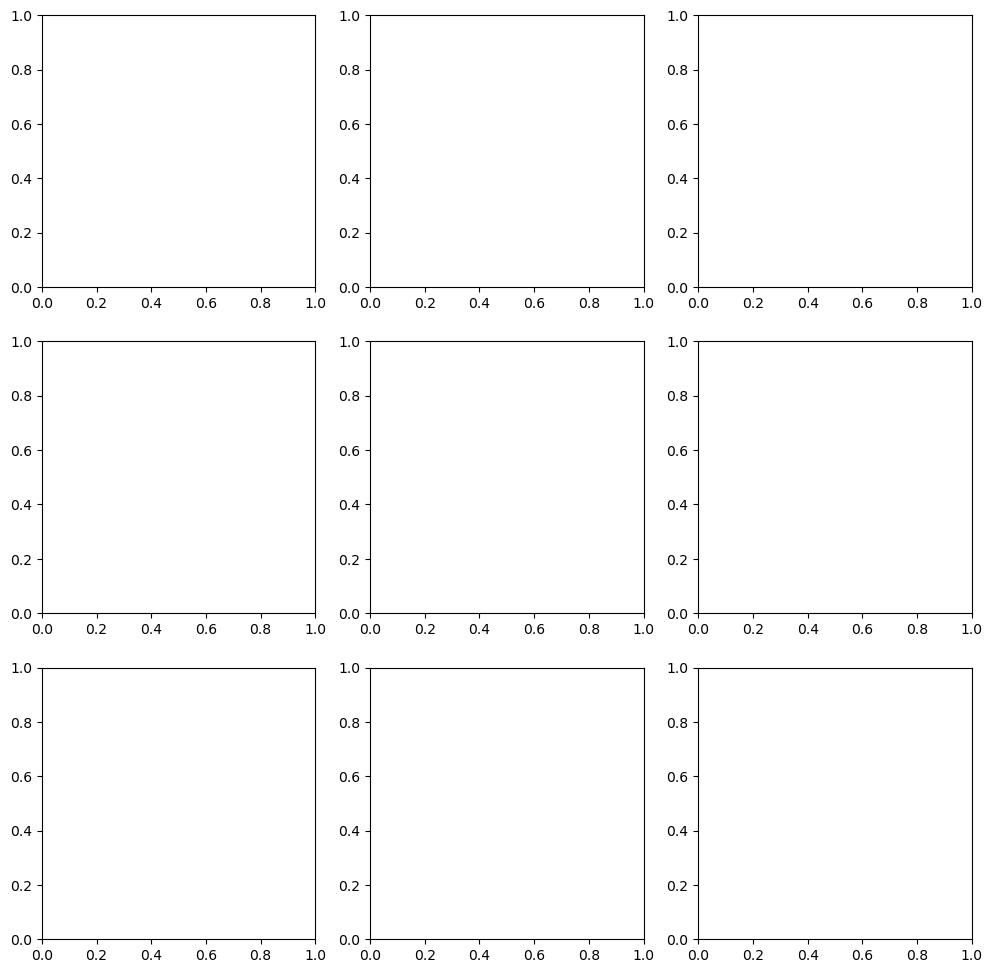

In [51]:
from matplotlib.pylab import amax

cmap = 'coolwarm'

f, ax = plt.subplots(nrows=len(model_names), ncols=len(coefs), figsize=(4*len(coefs), 4*len(model_names)))

max_val = 0
for j, coef in enumerate(coefs):

    for i, model_name in enumerate(model_names):

        # Aggregate and preproces.
        #img_arr = relevances_processed[j][model_name]
        img_arr = np.stack(relevances[j][model_name]).mean(axis=0)
        img_arr = np.abs(img_arr) #/ np.abs(img_arr).max()
        max_val = max(max_val, img_arr.max())
        #img_arr[img_arr < 0.1] = 0.

for j, coef in enumerate(coefs):
    for i, model_name in enumerate(model_names):
        img_arr = np.stack(relevances[j][model_name]).mean(axis=0)
        img_arr = np.abs(img_arr) / max_val
        print(img_arr.max())

        # Set title to fold and model name.
        ax[i, j].set_title(f"Coef: {coef} - Model: {model_name}")
        ax[i, j].axis('off')
        cut_coords = (img_arr.shape[0]//2, img_arr.shape[1]//2, img_arr.shape[2]//2)

        # ax[0].set_title("Saggital cross-section")
        ax[i, j].imshow(np.rot90(img_arr[cut_coords[0], :, :]), cmap=cmap, vmin=0, vmax=1, aspect="equal")
        # ax[1].set_title("Coronal cross-section")
        #ax[i, j].imshow(np.rot90(img_arr[:, cut_coords[1], :]), cmap=cmap, vmin=0, vmax=1, aspect="equal")
        # ax[2].set_title("Axial cross-section")
        #ax[i, j].imshow(np.rot90(img_arr[:, :, cut_coords[2]]), cmap=cmap, vmin=0, vmax=1, aspect="equal")
plt.show()

### Sanity Check: Are there difference between brains, and if yes, where?

In [ ]:
# Sanity check. for fold 0 over coefs: plot image[0]
np.random.seed(RANDOM_STATE)  # Make sure a seed is set for reproducibility.
flip_proba = 0.0
y_flip = np.where(np.random.binomial(1, flip_proba, len(y)), 1 - y, y)

img_coefs = []
for i, coef in enumerate([0.0, 1, 2]):
    cv = StratifiedKFoldWithSyntheticResample(n_splits=5, sex_coef=coef, n_resamples=500, shuffle=True, random_state=RANDOM_STATE)
    imgs = []
    for fold, (train_index, val_index, test_index, test_index_orig) in enumerate(cv.split(np.zeros(len(y_flip)), Z, y_flip)):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y_flip[train_index], y_flip[val_index]
        Xy1mean = X_train[y_train.flatten() == 1].mean(axis=0)
        Xy2mean = X_train[y_train.flatten() == 0].mean(axis=0)
        Xydiff = Xy1mean - Xy2mean
        imgs.append(Xydiff)
    img_arr = np.stack(imgs).mean(axis=0)
    img_coefs.append(img_arr)

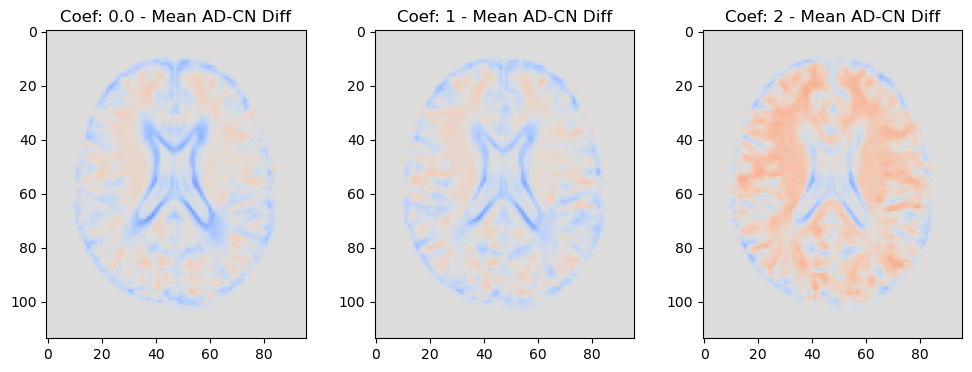

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
vmax = np.abs(np.stack(img_coefs)).max()
for i, coef in enumerate([0.0, 1, 2]):
    img_arr = img_coefs[i]
    cut_coords = (img_arr.shape[0]//2, img_arr.shape[1]//2, img_arr.shape[2]//2)
    ax[i].imshow(np.rot90(img_arr[:, :, cut_coords[2]]), cmap='coolwarm', vmin=-vmax, vmax=vmax)
    ax[i].set_title(f"Coef: {coef} - Mean AD-CN Diff")

In [ ]:
# Sanity check. for fold 0 over coefs: plot image[0]
np.random.seed(RANDOM_STATE)  # Make sure a seed is set for reproducibility.
flip_proba = 0.0
y_flip = np.where(np.random.binomial(1, flip_proba, len(y)), 1 - y, y)

img_coefs = []
for i, coef in enumerate([0.0, 1, 2]):
    cv = StratifiedKFoldWithSyntheticResample(n_splits=5, sex_coef=coef, n_resamples=500, shuffle=True, random_state=RANDOM_STATE)
    imgs = []
    for fold, (train_index, val_index, test_index, test_index_orig) in enumerate(cv.split(np.zeros(len(y_flip)), Z, y_flip)):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y_flip[train_index], y_flip[val_index]
        Z_train, Z_val = Z[train_index], Z[val_index]
        Xy1mean = X_train[Z_train.flatten() == 1].mean(axis=0)
        Xy2mean = X_train[Z_train.flatten() == -1].mean(axis=0)
        Xydiff = Xy1mean - Xy2mean
        imgs.append(Xydiff)
    img_arr = np.stack(imgs).mean(axis=0)
    img_coefs.append(img_arr)

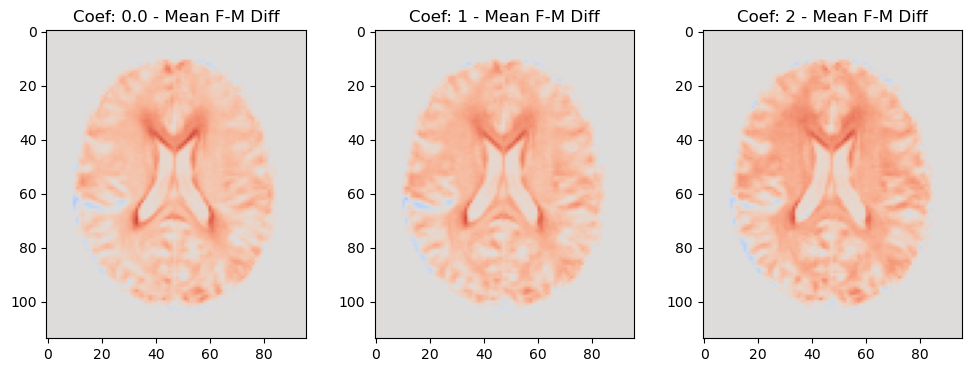

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
vmax = np.abs(np.stack(img_coefs)).max()
for i, coef in enumerate([0.0, 1, 2]):
    img_arr = img_coefs[i]
    cut_coords = (img_arr.shape[0]//2, img_arr.shape[1]//2, img_arr.shape[2]//2)
    ax[i].imshow(np.rot90(img_arr[:, :, cut_coords[2]]), cmap='coolwarm', vmin=-vmax, vmax=vmax)
    ax[i].set_title(f"Coef: {coef} - Mean F-M Diff")


---
# OLD STUFF

In [ ]:
from zennit.composites import EpsilonGammaBox
from zennit.canonizers import SequentialMergeBatchNorm
from zennit.attribution import Gradient

canonizers = [SequentialMergeBatchNorm()]
composite = EpsilonGammaBox(low=0., high=1., canonizers=canonizers)

for network in [nnb_deep, nnc_deep, ssn_deep, psn_deep]:
    relevances = []
    for i in range(len(test_dataset)):
    #for i in range(100):
        label = test_dataset[i]['label']
        covar = test_dataset[i]['covar']
        if label == 0:
            continue
        if covar[1] == 0:
            continue
        input = test_dataset[i]['image'].unsqueeze(0).to(GPU)
        ssn_deep.x = covar.unsqueeze(0).to(GPU)
        input.requires_grad = True
        ssn_deep.x.requires_grad = True

        with Gradient(model=network, composite=composite) as attributor:
            out, relevance = attributor(input)
        #relevance = (relevance - relevance.mean() / relevance.std())
        #relevances.append(torch.sqrt(torch.abs(relevance)))
        relevances.append(relevance)
        #print(f"IMG {i} CLS {label} - Relevance: {relevance.mean():,.6f}. +- {relevance.std():,.6f}")

    relevance = torch.stack(relevances).mean(dim=0)
        
    # Normalize.
    img_arr = relevance.squeeze().cpu().numpy()
    amax = np.abs(img_arr).max()
    cut_coords = (img_arr.shape[0]//2, img_arr.shape[1]//2, img_arr.shape[2]//2)
    cmap = 'coolwarm'

    f, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
    ax[0].set_title("Saggital cross-section")
    ax[0].imshow(np.rot90(img_arr[cut_coords[0], :, :]), cmap=cmap, vmin=-amax, vmax=amax, aspect="equal")
    ax[1].set_title("Coronal cross-section")
    ax[1].imshow(np.rot90(img_arr[:, cut_coords[1], :]), cmap=cmap, vmin=-amax, vmax=amax, aspect="equal")
    ax[2].set_title("Axial cross-section")
    ax[2].imshow(np.rot90(img_arr[:, :, cut_coords[2]]), cmap=cmap, vmin=-amax, vmax=amax, aspect="equal")
    plt.show()

In [ ]:
import types
def deep_forward_orth(self, u):
    h = self.model.backbone(u)
    eta_deep = self.model.deep_predictor(h) - self.x @ self.model.ortho_parameters
    return eta_deep

def deep_forward_psn(self, u):
    h = self.model.backbone(u)
    eta_deep = self.model.deep_predictor(h)
    return eta_deep

def deep_forward(self, u):
    h = self.backbone(u)
    eta_deep = self.deep_predictor(h)
    return eta_deep

### Cross Validated HEATMAPS!

In [ ]:
import types
import pickle

def deep_forward_orth(self, u):
    h = self.model.backbone(u)
    eta_deep = self.model.deep_predictor(h) - self.x @ self.model.ortho_parameters
    return eta_deep

def deep_forward_psn(self, u):
    h = self.model.backbone(u)
    eta_deep = self.model.deep_predictor(h)
    return eta_deep

def deep_forward(self, u):
    h = self.backbone(u)
    eta_deep = self.deep_predictor(h)
    return eta_deep

from zennit.composites import EpsilonGammaBox
from zennit.canonizers import SequentialMergeBatchNorm
from zennit.attribution import Gradient

canonizers = [SequentialMergeBatchNorm()]
composite = EpsilonGammaBox(low=0., high=1., canonizers=canonizers)

In [ ]:
# Per fold. Load models and training data. Estimate SSN. Compute relevance map over holdout X_test dataset. Save the results in a results folder.
output_dir = proj_path + "results/ADNI_SexAD_Synthetic_Study/2025-03-23_18-05-13_with_psn/coef=2/"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

In [ ]:
test_dataset = numpyCovarDataset(X_test, y_test, Z_test, transform=transforms.Compose(other_transforms))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8)
relevance_folds = []
cv = StratifiedKFoldWithSyntheticResample(n_splits=5, sex_coef=2., n_resamples=500, shuffle=True, random_state=RANDOM_STATE)
for fold, indices in enumerate(cv.split(np.zeros(len(y)), Z, y)):
    
    print(f"Fold {fold}")
    torch.cuda.empty_cache()
    gc.collect()

    # Load latest models from checkpoints.
    load_dir = proj_path + 'logs/ADNI_SexAD_Synthetic_Study/2025-03-23_14-35-21'
    with torch.no_grad():

        print(f":: Loading balanced neural network model.")
        nnb_deep = NeuralNetwork.load_from_checkpoint(glob(load_dir+f"/coef=0.0/neural_network_cv*.ckpt")[fold], model_params=model_params).to(GPU)
        with torch.no_grad():
            nnb_deep.deep_predictor.bias.fill_(0.)
        nnb_deep.forward = types.MethodType(deep_forward, nnb_deep)
        nnb_deep.eval()

        print(f":: Loading neural network model.")
        nnc_deep = NeuralNetwork.load_from_checkpoint(glob(load_dir+f"/coef=2/neural_network_cv*.ckpt")[fold], model_params=model_params).to(GPU)     
        with torch.no_grad():
            nnc_deep.deep_predictor.bias.fill_(0.)
        nnc_deep.forward = types.MethodType(deep_forward, nnc_deep)
        nnc_deep.eval()

        print(f":: Loading covariate neural network model.")
        cnet = CovarNeuralNetwork.load_from_checkpoint(glob(load_dir+f"/coef=2/covar_neural_network_cv*.ckpt")[fold], model_params=model_params).to(GPU)
        cnet.eval()

        # Load training data.
        print(f":: Loading training data.")
        X_train_conf, y_train_conf, Z_train_conf = X[indices[0]], y[indices[0]], Z[indices[0]]
        train_dataset_conf = numpyCovarDataset(X_train_conf, y_train_conf, Z_train_conf, transform=transforms.Compose(augmentations+other_transforms))
        train_loader_conf = DataLoader(train_dataset_conf, batch_size=batch_size, shuffle=True, num_workers=8)

        print(f":: Estimating post-hoc orthogonalized model.")
        #ssn_deep = PostHocIRLSModel(cnet, train_loader_conf, orthogonalize=True).to(GPU)
        ssn_deep = PostHocOrthogonalizedModel(cnet, train_loader_conf).to(GPU)
        ssn_deep.forward = types.MethodType(deep_forward_orth, ssn_deep)
        ssn_deep.eval()

        print(f":: Estimating TE model with Proj DE.")
        psn_deep = PostHocProjModel(net, train_loader_conf).to(GPU)
        psn_deep.forward = types.MethodType(deep_forward_psn, psn_deep)
        psn_deep.eval()
    
    # Compute relevance maps.
    print(f":: Computing relevance maps.")
    relevances = {
        'net_bal': [],
        'net': [],
        'ssn_deep': [],
        'psn_deep': []
    }
    for key, network in zip(relevances.keys(), [nnb_deep, nnc_deep, ssn_deep, psn_deep]):
        print(f":: :: Computing relevance map for {network.__class__.__name__}.")
        rels = []
        for i in range(len(test_dataset)):
            label = test_dataset[i]['label']
            if label == 0: 
                continue  # Only AD samples.
            if test_dataset[i]['covar'][1] == 0:
                continue  # Only Female samples.
            input = test_dataset[i]['image'].unsqueeze(0).to(GPU)
            ssn_deep.x = test_dataset[i]['covar'].unsqueeze(0).to(GPU)
            input.requires_grad = True
            with Gradient(model=network, composite=composite) as attributor:
                out, relevance = attributor(input)
            rels.append(torch.sqrt(torch.abs(relevance)))
        rel = torch.stack(rels).mean(dim=0)
        relevances[key] = rel
        # Save relevance map.
        img_arr = rel.squeeze().cpu().numpy()
        with open(f"{output_dir}/{key}_relevance_fold{fold}.pkl", "wb") as f:
            pickle.dump(img_arr, f)
        # Save relevance map as image.
        cut_coords = (img_arr.shape[0]//2, img_arr.shape[1]//2, img_arr.shape[2]//2)
        cmap = 'coolwarm'
        f, ax = plt.subplots(nrows=1, ncols=3, figsize=(9, 3))
        amax = np.abs(img_arr).max()
        ax[0].set_title("Saggital cross-section")
        ax[0].imshow(np.rot90(img_arr[cut_coords[0], :, :]), cmap=cmap, vmin=0, vmax=amax, aspect="equal")
        ax[1].set_title("Coronal cross-section")
        ax[1].imshow(np.rot90(img_arr[:, cut_coords[1], :]), cmap=cmap, vmin=0, vmax=amax, aspect="equal")
        ax[2].set_title("Axial cross-section")
        ax[2].imshow(np.rot90(img_arr[:, :, cut_coords[2]]), cmap=cmap, vmin=0, vmax=amax, aspect="equal")
        plt.tight_layout()
        plt.savefig(f"{output_dir}/{key}_relevance_fold{fold}.png")
        plt.close()
    relevance_folds.append(relevances)

### Load relevance maps and aggregate over folds and plot.

In [ ]:
output_dir = proj_path + "results/ADNI_SexAD_Synthetic_Study/2025-03-23_18-05-13_with_psn/coef=2/"

In [ ]:
# Load relevance maps.
relevance_folds = []
for fold in range(4):
    relevances = {}
    for key in ['net_bal', 'net', 'ssn_deep', 'psn_deep']:
        with open(f"{output_dir}/{key}_relevance_fold{fold}.pkl", "rb") as f:
            img_arr = pickle.load(f)
        relevances[key] = img_arr
    relevance_folds.append(relevances)

In [ ]:
# Aggregate relevance maps.
relevance_aggregated = {}
for key in ['net_bal', 'net', 'ssn_deep', 'psn_deep']:
    img_arr = np.stack([relevance_folds[fold][key] for fold in range(4)]).mean(axis=0)
    relevance_aggregated[key] = img_arr
    # Save relevance map.
    with open(f"{output_dir}/{key}_relevance_aggregated.pkl", "wb") as f:
        pickle.dump(img_arr, f)
    # Save relevance map as image.
    cut_coords = (img_arr.shape[0]//2, img_arr.shape[1]//2, img_arr.shape[2]//2)
    cmap = 'coolwarm'
    f, ax = plt.subplots(nrows=1, ncols=3, figsize=(9, 3))
    amax = np.abs(img_arr).max()
    ax[0].set_title("Saggital cross-section")
    ax[0].imshow(np.rot90(img_arr[cut_coords[0], :, :]), cmap=cmap, vmin=0, vmax=amax, aspect="equal")
    ax[1].set_title("Coronal cross-section")
    ax[1].imshow(np.rot90(img_arr[:, cut_coords[1], :]), cmap=cmap, vmin=0, vmax=amax, aspect="equal")
    ax[2].set_title("Axial cross-section")
    ax[2].imshow(np.rot90(img_arr[:, :, cut_coords[2]]), cmap=cmap, vmin=0, vmax=amax, aspect="equal")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/aggregated_{key}_relevance.png")
    plt.close()

In [ ]:
# Save relevance map as image. Calculate one amax for all images.
cut_coords = (img_arr.shape[0]//2, img_arr.shape[1]//2, img_arr.shape[2]//2)
cmap = 'coolwar'
f, ax = plt.subplots(nrows=1, ncols=3, figsize=(9, 3))
for i, key in enumerate(['net_bal', 'net', 'ssn_deep', 'psn_deep']):
    img_arr = relevance_aggregated[key]
    amax = np.abs(img_arr).max()
    ax[i].set_title(key)
    ax[i].imshow(np.rot90(img_arr[cut_coords[0], :, :]), cmap=cmap, vmin=0, vmax=amax, aspect="equal")
plt.tight_layout()
plt.show()
f, ax = plt.subplots(nrows=1, ncols=3, figsize=(9, 3))
for i, key in enumerate(['net_bal', 'net', 'ssn_deep', 'psn_deep']):
    img_arr = relevance_aggregated[key]
    amax = np.abs(img_arr).max()
    ax[i].set_title(key)
    ax[i].imshow(np.rot90(img_arr[:, cut_coords[1], :]), cmap=cmap, vmin=0, vmax=amax, aspect="equal")
plt.tight_layout()
plt.show()
f, ax = plt.subplots(nrows=1, ncols=3, figsize=(9, 3))
for i, key in enumerate(['net_bal', 'net', 'ssn_deep', 'psn_deep']):
    img_arr = relevance_aggregated[key]
    amax = np.abs(img_arr).max()
    ax[i].set_title(key)
    ax[i].imshow(np.rot90(img_arr[:, :, cut_coords[2]]), cmap=cmap, vmin=0, vmax=amax, aspect="equal")
plt.tight_layout()
plt.show()


In [ ]:
#latest_results_dir = "/ritter/share/projects/manuel_orthgnl/logs/UKBB_AgeSex_Synthetic_Study/2024-04-04_17-37-20"
#results = pd.read_csv(latest_results_dir+"/results.csv")
#results

## Results plots

In [ ]:
display(results)

In [ ]:
age_std = np.std(data_adni['age'][:])
results['sex_coef_estimate_fix'] = results['sex_coef_estimate'] / age_std

In [ ]:
import warnings
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

# Lineplots with three subplots of balanced accuracy over train, test and test ood datasets and same y axis limits.
plt.figure(figsize=(18, 4))
#plt.subplot(1, 3, 1)
#sns.lineplot(data=results, x='sex_coef', y='train_bacc', hue='model')
#plt.ylim(0.48, 1)
#plt.title('Train Balanced Accuracy')
plt.subplot(1, 3, 1)
sns.lineplot(data=results, x='sex_coef', y='test_bacc', hue='model')
plt.ylim(0., 1)
plt.xlabel('Age Coefficient')
plt.ylabel('Balanced Accuracy')
plt.title('Test data set')
plt.subplot(1, 3, 2)
sns.lineplot(data=results, x='sex_coef', y='test_ood_bacc', hue='model', legend=None)
plt.ylim(0., 1.0)
plt.xlabel('Age Coefficient')
plt.ylabel('Balanced Accuracy')
plt.title('Flipped test data set')
plt.subplot(1, 3, 3)
sns.lineplot(data=results, x='sex_coef', y='sex_coef_estimate_fix', hue='model', legend=None)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Age Coefficient')
plt.ylabel('Estimated Age Coefficient')
plt.title('Comparison of coefficients')
# Show plots.
plt.show()

In [ ]:
quit()

In [ ]:
# Reload model checkpoints for Semi Structured Network and get predictions.
checkpoint_files = glob("/ritter/share/projects/manuel_orthgnl/notebooks/analysis/checkpoints/*.ckpt")

In [ ]:
cv = StratifiedKFoldWithSyntheticResample(n_splits=6, sex_coef=1.0, n_resamples=2000, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
for fold, (train_index, val_index, test_index, test_index_orig) in enumerate(cv.split(np.zeros(len(yu)), Zu, yu)):
    if fold == 5:
        # Split data.
        X_train, X_val, X_test, X_test_orig = Xu[train_index], Xu[val_index], Xu[test_index], Xu[test_index_orig]
        y_train, y_val, y_test, y_test_orig = yu[train_index], yu[val_index], yu[test_index], yu[test_index_orig]
        Z_train, Z_val, Z_test, Z_test_orig = Zu[train_index], Zu[val_index], Zu[test_index], Zu[test_index_orig]
        # Normalize Z.
        mu, std = np.mean(Z_train[:, 1]), np.std(Z_train[:,1])
        Z_train[:, 1] = (Z_train[:, 1] - mu) / std
        Z_val[:, 1] = (Z_val[:, 1] - mu) / std
        Z_test[:, 1] = (Z_test[:, 1] - mu) / std
        Z_test_orig[:, 1] = (Z_test_orig[:, 1] - mu) / std
        # Create datasets.
        train_dataset = numpyCovarDataset(X_train, y_train, Z_train, transform=transforms.Compose(augmentations+other_transforms))
        val_dataset = numpyCovarDataset(X_val, y_val, Z_val, transform=transforms.Compose(other_transforms))
        test_dataset = numpyCovarDataset(X_test, y_test, Z_test, transform=transforms.Compose(other_transforms))
        test_dataset_orig = numpyCovarDataset(X_test_orig, y_test_orig, Z_test_orig, transform=transforms.Compose(other_transforms))
        # Create dataloaders.
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=8)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8)
        test_loader_orig = DataLoader(test_dataset_orig, batch_size=batch_size, shuffle=False, num_workers=8)

In [ ]:
# Load best model.
model = NeuralNetwork.load_from_checkpoint("/ritter/share/projects/manuel_orthgnl/notebooks/analysis/checkpoints/epoch=34-step=7000.ckpt", model_params={**model_params, **{'num_covars': Z_train.shape[1], 'bias': False}})
# Post-hoc orthogonalize model.
model = PostHocOrthogonalizedModel(model, train_loader).to(GPU)

In [ ]:
# Get predictions on test and OOD test sets.
p_train = get_predictions(model, train_loader)
p_test = get_predictions(model, test_loader)
p_test_ood = get_predictions(model, test_loader_orig)

In [ ]:
# Update results.
print({'sex_coef': 1.0, 'fold': fold, 'model': 'Semi-structured Network (PHO)', 'sex_coef_estimate': model.coefs()[1],
                            'train_bacc': balanced_accuracy_score(y_train, p_train>0.5), 'test_bacc': balanced_accuracy_score(y_test, p_test>0.5), 'test_ood_bacc': balanced_accuracy_score(y_test_orig, p_test_ood>0.5),
                            'train_d2': deviance_explained(y_train, p_train), 'test_d2': deviance_explained(y_test, p_test), 'test_ood_d2': deviance_explained(y_test_orig, p_test_ood)})

In [ ]:
p_test_ood_integrate = get_predictions_integrate(model, test_loader_orig, Z_train)

In [ ]:
balanced_accuracy_score(y_test_orig, p_test_ood_integrate>0.5)